In [36]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
xx = np.array([-0.51, 51.2])
yy = np.array([0.33, 51.6])
means = [xx.mean(), yy.mean()]  
stds = [xx.std() / 3, yy.std() / 3]
corr = 0.8         # correlation
covs = [[stds[0]**2          , stds[0]*stds[1]*corr], 
        [stds[0]*stds[1]*corr,           stds[1]**2]] 

m = np.random.multivariate_normal(means, covs, 1000).T

In [38]:
df=pd.DataFrame()

In [39]:

df['exp(in months)']=m[0]
df['salary(in thousands)']=m[1]

In [40]:

df.head()

,exp(in months),salary(in thousands)
0,11.421311,14.730800
1,27.650466,25.399040
2,44.075217,44.237667
3,23.212627,17.833643
4,28.266351,34.877213


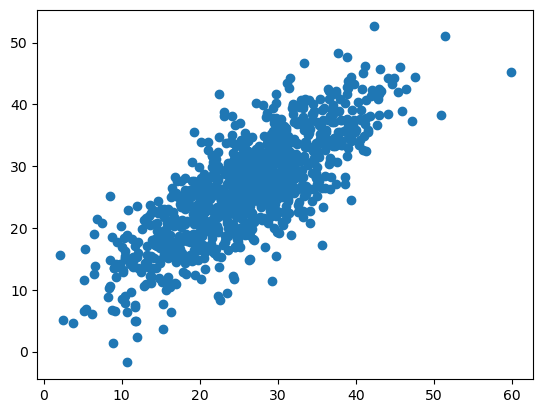

In [41]:
plt.scatter(df['exp(in months)'],df['salary(in thousands)'])

In [42]:
X=df.iloc[:,0:1].values
y=df.iloc[:,1].values

In [43]:
print(X.shape)
print(y.shape)

(1000, 1)
(1000,)


In [44]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [45]:
print(X_train.shape)
print(X_test.shape)

(800, 1)
(200, 1)


In [46]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()

In [47]:
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [48]:
y_pred = regressor.predict(X_test)

In [49]:
# Finding the Coefs and intercept

# Equation of line is given by y=mx+b
# y=0.81*x + 5.50
# m ---> slope
# b ---> intercept

# X coefficient
print(regressor.coef_[0])

# Y intercept
print(regressor.intercept_)

0.7902847048667893
5.832960016936688


In [56]:
df_error = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

df_error['Error'] = df_error['Actual'] - df_error['Predicted']


In [58]:
df_error

,Actual,Predicted,Error
0,25.128009,29.625609,-4.497600
1,28.189156,33.460759,-5.271604
2,27.587549,19.337626,8.249922
3,45.805422,39.894724,5.910699
4,26.754127,32.432921,-5.678794
...,...,...,...
195,17.179606,17.087676,0.091930
196,11.032792,16.725953,-5.693161
197,34.226398,34.620272,-0.393874
198,30.491741,27.818028,2.673713


In [60]:
# Mean Absolute Error

from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test, y_pred)

4.02572480671531

In [62]:

# Mean Squared Error

from sklearn.metrics import mean_squared_error
mean_squared_error(y_test,y_pred)

25.34186495381759

In [64]:
# Root Mean Squared Error
mse=mean_squared_error(y_test,y_pred)

np.sqrt(mse)

np.float64(5.034070416056731)

In [66]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6201298285163158

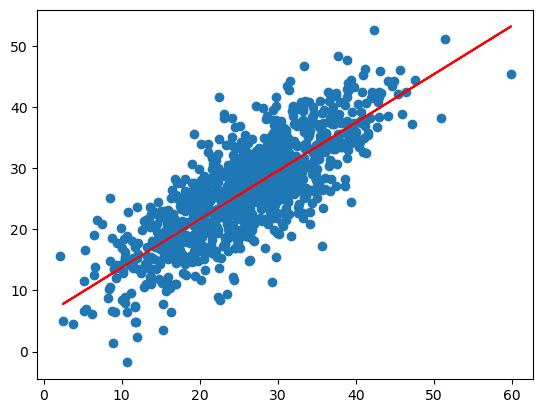

In [68]:
# Visualising the regression line
plt.plot(X_train,regressor.predict(X_train), color='red')
plt.scatter(df['exp(in months)'],df['salary(in thousands)'])